In [2]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import resource
resource.getrusage(resource.RUSAGE_SELF)[2]/1024
#    np.savez(filename,ai_pol_k=ai_pol_k,bi_pol_k=bi_pol_k,k_values=k_values,n_factors=n_factors,
#             t_values=t_values, gauss=gauss, nums = nums_mag, hs = hs_mag, rs=rs_mag  )

d0=np.load('data0a.npz')
d1=np.load('data1a.npz')
d2=np.load('data2a.npz')

#r0=np.load('results0.npz')
#r1=np.load('results1.npz')
#r2=np.load('results2.npz')
#
#momentum_0=r0['momentum0m']
#momentum_0L=r0['momentum0l']
#edges0=r0['edges0']
#boundaries0=r0['boundaries0']
#mst0=r0['mst0']
#lor0=r0['lor0']
#poyn0=r0['poyn0']
#
#edges1=r1['edges1']
#boundaries1=r1['boundaries1']
#mst1=r1['mst1']
#lor1=r1['lor1']
#poyn1=r1['poyn1']
#
#edges2=r2['edges2']
#boundaries2=r2['boundaries2']
#mst2=r2['mst2']
#lor2=r2['lor2']
#poyn2=r2['poyn2']

ModuleNotFoundError: No module named 'ipympl'

# Physical Positions

In [33]:
t_step = .05

zpos=[0]
nums0=d0['nums']
hs0=d0['hs']
rs0=d0['rs']
for ni in range(len(nums0)):
    for k in range(nums0[ni]):
# This follows the sandwiched structure of the individual periods
        zpos.append(hs0[ni]*rs0[ni]/2)
        zpos.append(0)
        zpos.append(hs0[ni]*(1-rs0[ni]))
        zpos.append(0)
        zpos.append(hs0[ni]*rs0[ni]/2)
       
zpos0=np.cumsum(np.array(zpos)) # Adding widths so proper distances from an origin at the left hand side are calculated
inds0=d0['n_factors'] # Indices

zpos=[0]
nums1=d1['nums']
hs1=d1['hs']
rs1=d1['rs']
for ni in range(len(nums1)):
    for k in range(nums1[ni]):
        zpos.append(hs1[ni]*rs1[ni]/2)
        zpos.append(0)
        zpos.append(hs1[ni]*(1-rs1[ni]))
        zpos.append(0)
        zpos.append(hs1[ni]*rs1[ni]/2)
zpos1=np.cumsum(np.array(zpos))
inds1=d1['n_factors']

zpos=[0]
nums2=d2['nums']
hs2=d2['hs']
rs2=d2['rs']
for ni in range(len(nums2)):
    for k in range(nums2[ni]):
        zpos.append(hs2[ni]*rs2[ni]/2)
        zpos.append(0)
        zpos.append(hs2[ni]*(1-rs2[ni]))
        zpos.append(0)
        zpos.append(hs2[ni]*rs2[ni]/2)
zpos2=np.cumsum(np.array(zpos))
inds2=d2['n_factors']

# Same for all 3 optical systems
tv = d0['t_values']
kv = d0['k_values']

# Intensity

## Spectral Domain

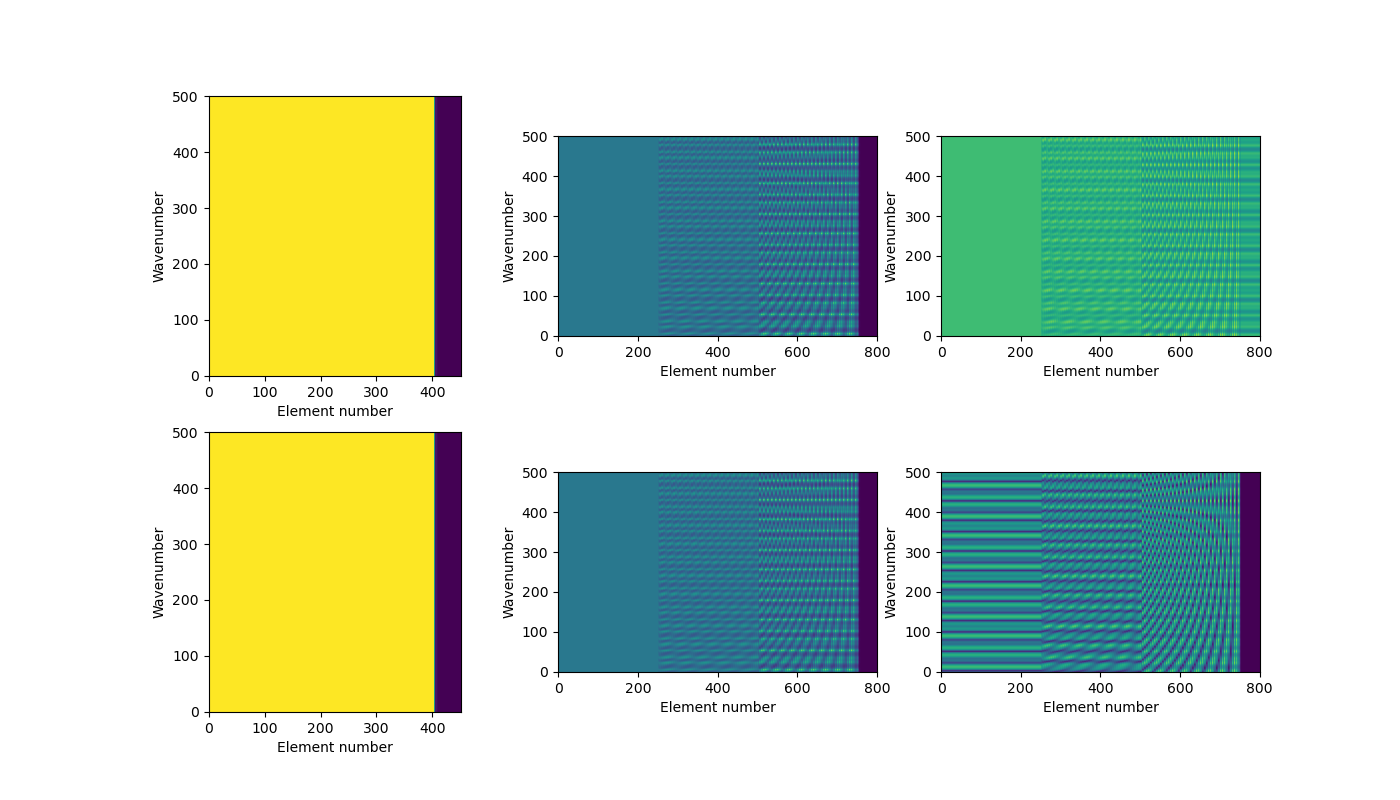

In [5]:
#spectral domain, amplitude

fig, ax = plt.subplots(2,3,figsize=(14,8))
Z=np.abs(d0['ai_pol_k'])
ax[0,0].imshow(Z, interpolation='bilinear', origin='lower', vmax=abs(Z).max(), vmin=0)
ax[0,0].set_xlabel('Element number')
ax[0,0].set_ylabel('Wavenumber')

Z=np.abs(d1['ai_pol_k'])
ax[0,1].imshow(Z, interpolation='bilinear',  origin='lower', vmax=abs(Z).max(), vmin=0)
ax[0,1].set_xlabel('Element number')
ax[0,1].set_ylabel('Wavenumber')

Z=np.abs(d2['ai_pol_k'])
ax[0,2].imshow(Z, interpolation='bilinear',  origin='lower', vmax=abs(Z).max(), vmin=0);
ax[0,2].set_xlabel('Element number')
ax[0,2].set_ylabel('Wavenumber')

Z=np.abs(d0['bi_pol_k'])
ax[1,0].imshow(Z, interpolation='bilinear',  origin='lower', vmax=abs(Z).max(), vmin=0)
ax[1,0].set_xlabel('Element number')
ax[1,0].set_ylabel('Wavenumber')

Z=np.abs(d1['bi_pol_k'])
ax[1,1].imshow(Z, interpolation='bilinear',  origin='lower', vmax=abs(Z).max(), vmin=0)
ax[1,1].set_xlabel('Element number')
ax[1,1].set_ylabel('Wavenumber')

Z=np.abs(d2['bi_pol_k'])
ax[1,2].imshow(Z, interpolation='bilinear',  origin='lower', vmax=abs(Z).max(), vmin=0);
ax[1,2].set_xlabel('Element number')
ax[1,2].set_ylabel('Wavenumber')
plt.show()

## Time Domain

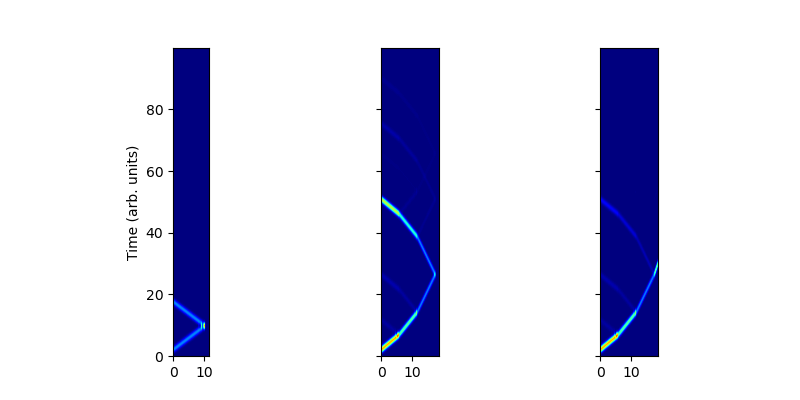

In [6]:
#time domain, intensity

c=1;
mt=np.exp(-1j * np.outer(d0['t_values'],d0['k_values']) * c)*d0['gauss'];
zmax0=np.sum(d0['nums']*d0['hs'])
zmax1=np.sum(d1['nums']*d1['hs'])
zmax2=np.sum(d2['nums']*d2['hs'])
tmax=d0['t_values'][-1]

fig, ax = plt.subplots(1,3,figsize=(8,4),sharey=True)
Z=np.abs(mt@(d0['ai_pol_k']+d0['bi_pol_k']))**2
ax[0].set_ylabel('Time (arb. units)')
ax[0].imshow(Z, interpolation='bilinear',  origin='lower',
            extent=[0, zmax0, 0, tmax],
            vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
Z=np.abs(mt@(d1['ai_pol_k']+d1['bi_pol_k']))**2
ax[1].imshow(Z, interpolation='bilinear',  origin='lower',
             extent=[0, zmax1, 0, tmax],
               vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
Z=np.abs(mt@(d2['ai_pol_k']+d2['bi_pol_k']))**2
ax[2].imshow(Z, interpolation='bilinear',  origin='lower',
             extent=[0, zmax2, 0, tmax],
               vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet);

### Plot

CPU times: user 20.6 s, sys: 8.51 s, total: 29.1 s
Wall time: 15.2 s


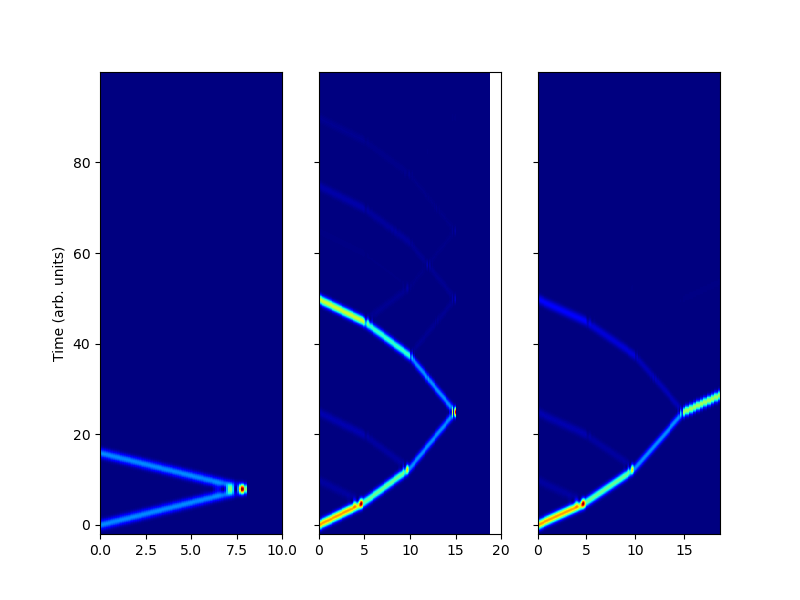

In [7]:
%%time
#time domain, intensity
c=1;
mt=np.exp(-1j * np.outer(tv,kv) * c)*d0['gauss'];

fig, ax = plt.subplots(1,3,figsize=(8,6),sharey=True)
Z=np.abs(mt@(d0['ai_pol_k']+d0['bi_pol_k']))**2
ax[0].pcolor(zpos0,tv,Z,  vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
ax[0].set_xlim([0,10])
Z=np.abs(mt@(d1['ai_pol_k']+d1['bi_pol_k']))**2
ax[1].pcolor(zpos1,tv,Z,  vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
ax[1].set_xlim([0,20])
ax[0].set_ylabel('Time (arb. units)')
Z=np.abs(mt@(d2['ai_pol_k']+d2['bi_pol_k']))**2
ax[2].pcolor(zpos2,tv,Z, vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet);

# MST

## Vacuum + DBR

### Calculation

In [34]:
%%time
# time domain, MST (z)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d0['gauss'];
inds0=d0['n_factors'][0::5]
aik=(d0['ai_pol_k']/len(kv))[:,0::5]
bik=(d0['bi_pol_k']/len(kv))[:,0::5]

mst0=1j*np.zeros((aik.shape[1],len(tv)))

for i in tqdm(range(aik.shape[1])):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mst0[i,:]= -inds0[i]**2/mu0*np.diag(ait.conj()@np.outer(kv,kv)@(ait).T) \
            - inds0[i]**2/mu0*np.diag(bit.conj()@np.outer(kv,kv)@(bit).T)
    
edges0 = np.cumsum(nums0)
boundaries0 = np.cumsum(nums0*hs0)
mst0 = np.real(mst0)

100%|██████████| 91/91 [00:23<00:00,  3.89it/s]

CPU times: user 10min 6s, sys: 8min 25s, total: 18min 32s
Wall time: 23.6 s


In [35]:
mlay0=np.diff(mst0,axis=0)
momentum_0 = np.cumsum(mlay0[edges0[0]:])[-1]*t_step/2
momentum_0

0.4881339216033709

### Plots

#### Time, Positions, Magnitude

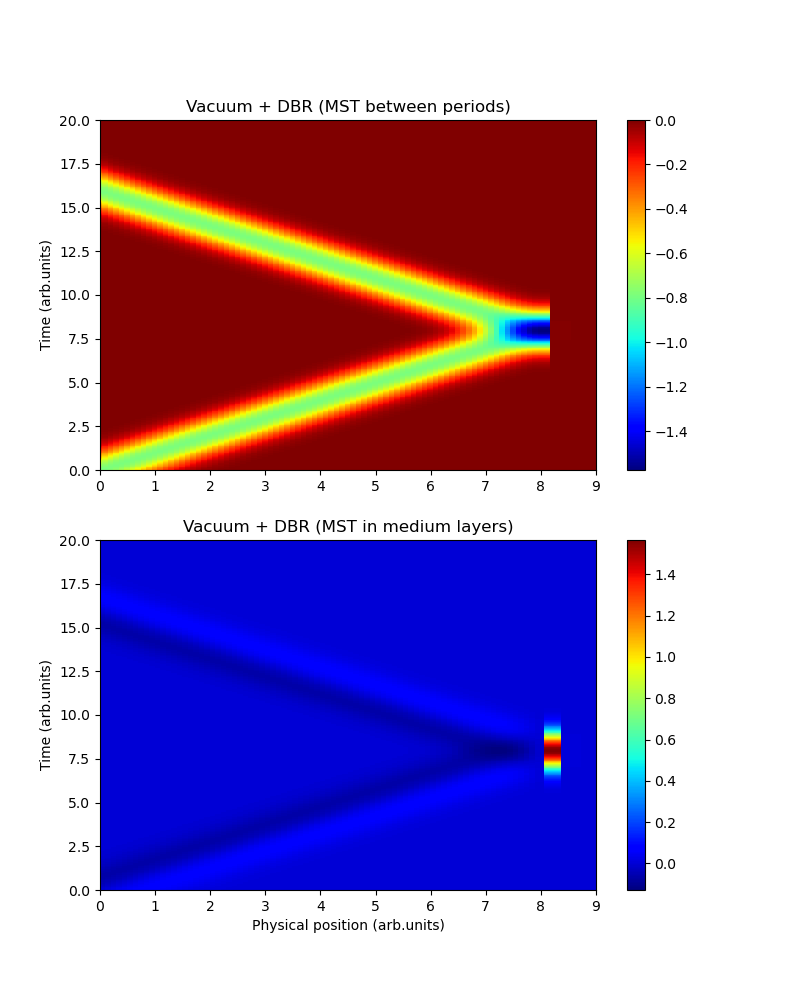

In [6]:
fig, ax = plt.subplots(2,1,figsize=(8,10))
Z=np.real(mst0[0::5,:]).T #Already just at periods edges
pc0=ax[0].pcolor(zpos0[0::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax[0].set_xlim([0,9])
ax[0].set_title('Vacuum + DBR (MST between periods)')
#ax[0].set_xlabel('Physical position (arb.units)')
ax[0].set_ylabel('Time (arb.units)')
ax[0].set_ylim([0,20])
cbar0 = fig.colorbar(pc0)

Zd=np.diff(Z[:,:],axis=1)
pc1=ax[1].pcolor((zpos0[2::5]+zpos0[3::5])/2, tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
ax[1].set_xlim([0,9])
ax[1].set_title('Vacuum + DBR (MST in medium layers)')
ax[1].set_xlabel('Physical position (arb.units)')
ax[1].set_ylabel('Time (arb.units)')
ax[1].set_ylim([0,20])
cbar1 = fig.colorbar(pc1)

#### Impulse over Time

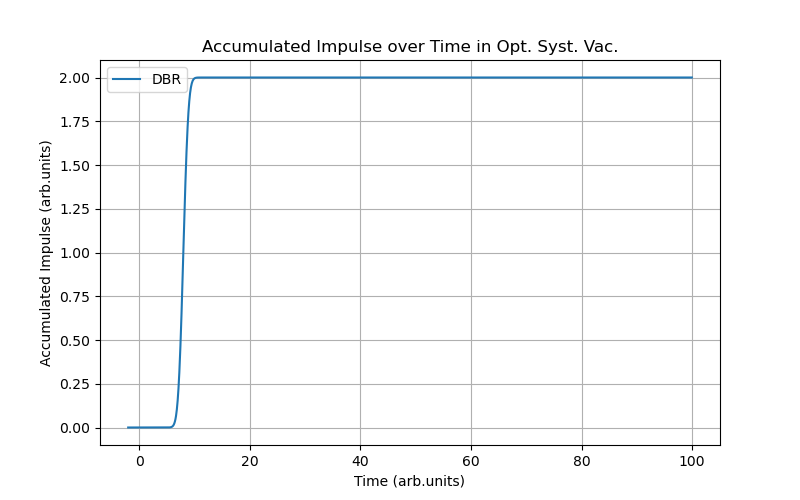

0.4881339216033709


In [5]:
edges0 = np.cumsum(nums0)

plt.figure(figsize=(8,5))
plt.plot(tv,np.cumsum(np.sum(mlay0[edges0[0]:],axis=0))*t_step/momentum_0,label='DBR')
plt.title('Accumulated Impulse over Time in Opt. Syst. Vac.')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()
print(momentum_0)

## Vacuum + Crystal 1 + Crystal 2 + DBR

### Calculation

In [6]:
%%time
# time domain, MST (z)

c, eps0, mu0=1, 1, 1
inds1=d1['n_factors'][0::5]
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss'];
aik=(d1['ai_pol_k']/len(kv))[:,0::5] # Only at period edges
bik=(d1['bi_pol_k']/len(kv))[:,0::5]

mst1=1j*np.zeros((aik.shape[1],len(tv)))

for i in tqdm(range(aik.shape[1])): # At each elements position, compute mst
    ait=mt*aik[:,i].T # Coordinates t,k
    bit=mt*bik[:,i].T
    mst1[i,:]= -inds1[i]**2/mu0*np.diag(ait.conj()@np.outer(kv,kv)@(ait).T) \
            - inds1[i]**2/mu0*np.diag((bit).conj()@np.outer(kv,kv)@(bit).T)

edges1 = np.cumsum(nums1)
boundaries1 = np.cumsum(nums1*hs1)
mst1 = np.real(mst1)

100%|██████████| 161/161 [00:51<00:00,  3.14it/s]

CPU times: user 19min 44s, sys: 20min 54s, total: 40min 38s
Wall time: 51.5 s


In [7]:
mlay1=np.diff(mst1,axis=0) # [0::5] already just at edges

### Plots

#### Time, Positions, Magnitude

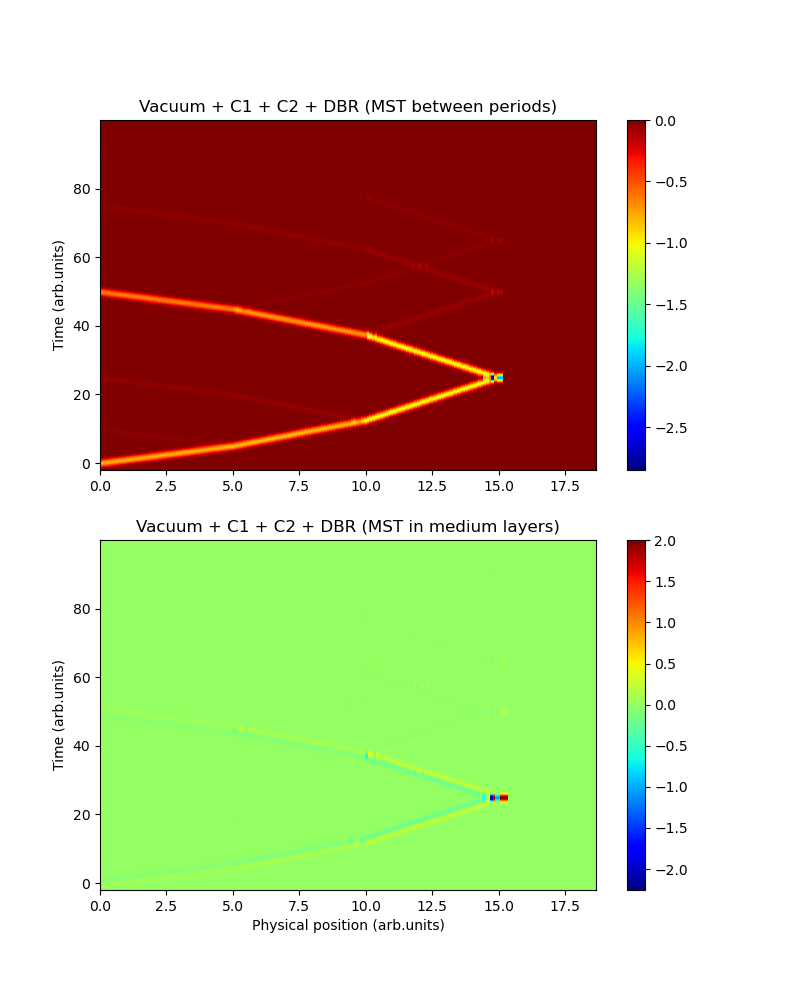

In [8]:
fig, ax = plt.subplots(2,1,figsize=(8,10))
Z=mst1[0::5].T # [0::5,:] already just at edges
pc0=ax[0].pcolor(zpos1[0::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax[0].set_xlim([0,zpos1[0::5][-1]])
ax[0].set_title('Vacuum + C1 + C2 + DBR (MST between periods)')
#ax[0].set_xlabel('Physical position (arb.units)')
ax[0].set_ylabel('Time (arb.units)')
cbar0 = fig.colorbar(pc0)

Zd=np.diff(Z,axis=1)
pc1=ax[1].pcolor((zpos1[2::5]+zpos1[3::5])/2, tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
ax[1].set_xlim([0,zpos1[0::5][-1]])
ax[1].set_title('Vacuum + C1 + C2 + DBR (MST in medium layers)')
ax[1].set_xlabel('Physical position (arb.units)')
ax[1].set_ylabel('Time (arb.units)')
cbar1 = fig.colorbar(pc1)

#### Impulse over Time

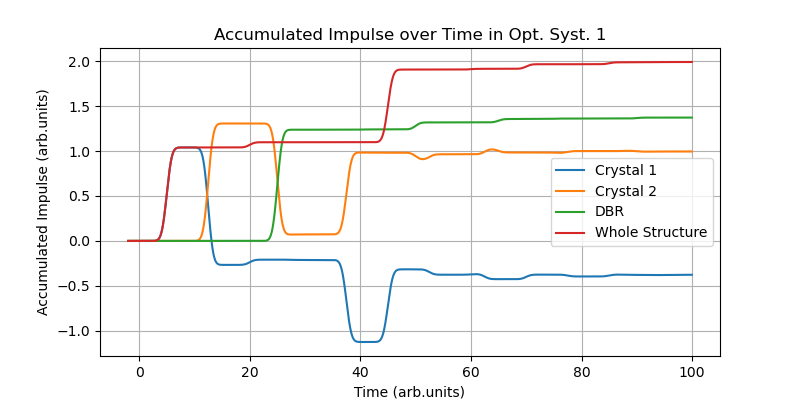

In [8]:
#mlay1=np.diff(mst1[0::5],axis=0) # [0::5] already just at edges
edges1 = np.cumsum(nums1)
plt.figure(figsize=(8,4))
#mlay1=np.real(mst1) # [0::5] already just at edges
#plt.plot(tv,np.cumsum(mlay1[edges1[1]]-mlay1[edges1[0]])/momentum_0,label='Crystal 1')
#plt.plot(tv,np.cumsum(mlay1[edges1[2]]-mlay1[edges1[1]])/momentum_0,label='Crystal 2')
#plt.plot(tv,np.cumsum(mlay1[edges1[3]]-mlay1[edges1[2]])/momentum_0,label='DBR')
#plt.plot(tv,np.cumsum(mlay1[edges1[3]]-mlay1[edges1[0]])/momentum_0,label='Whole Structure')
plt.plot(tv,np.cumsum(np.sum(mlay1[edges1[0]:edges1[1]],axis=0))*t_step/momentum_0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(mlay1[edges1[1]:edges1[2]],axis=0))*t_step/momentum_0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(mlay1[edges1[2]:],axis=0))*t_step/momentum_0,label='DBR')
plt.plot(tv,np.cumsum(np.sum(mlay1[edges1[0]:],axis=0))*t_step/momentum_0,label='Whole Structure')
plt.title('Accumulated Impulse over Time in Opt. Syst. 1')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

## Vacuum + Crystal 1 + Crystal 2 + Vacuum

### Calculation

In [9]:
%%time
# time domain, MST (z)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d2['gauss'];
inds2=d2['n_factors'][0::5]
aik=(d2['ai_pol_k']/len(kv))[:,0::5] # Only at period edges
bik=(d2['bi_pol_k']/len(kv))[:,0::5]

mst2=1j*np.zeros((aik.shape[1],len(tv)))

for i in tqdm(range(aik.shape[1])): # At each elements position, compute mst
    ait=mt*aik[:,i].T # Coordinates t,k
    bit=mt*bik[:,i].T
    mst2[i,:]= -inds2[i]**2/mu0*np.diag(ait.conj()@np.outer(kv,kv)@(ait).T) \
            - inds2[i]**2/mu0*np.diag((bit).conj()@np.outer(kv,kv)@(bit).T)

edges2 = np.cumsum(nums2)
boundaries2 = np.cumsum(nums2*hs2)
mst2 = np.real(mst2)

100%|██████████| 161/161 [00:51<00:00,  3.11it/s]

CPU times: user 19min 56s, sys: 21min 1s, total: 40min 57s
Wall time: 51.8 s


In [10]:
mlay2=np.diff(mst2,axis=0) # [0::5] already just at edges

### Plots

#### Time, Positions, Magnitude

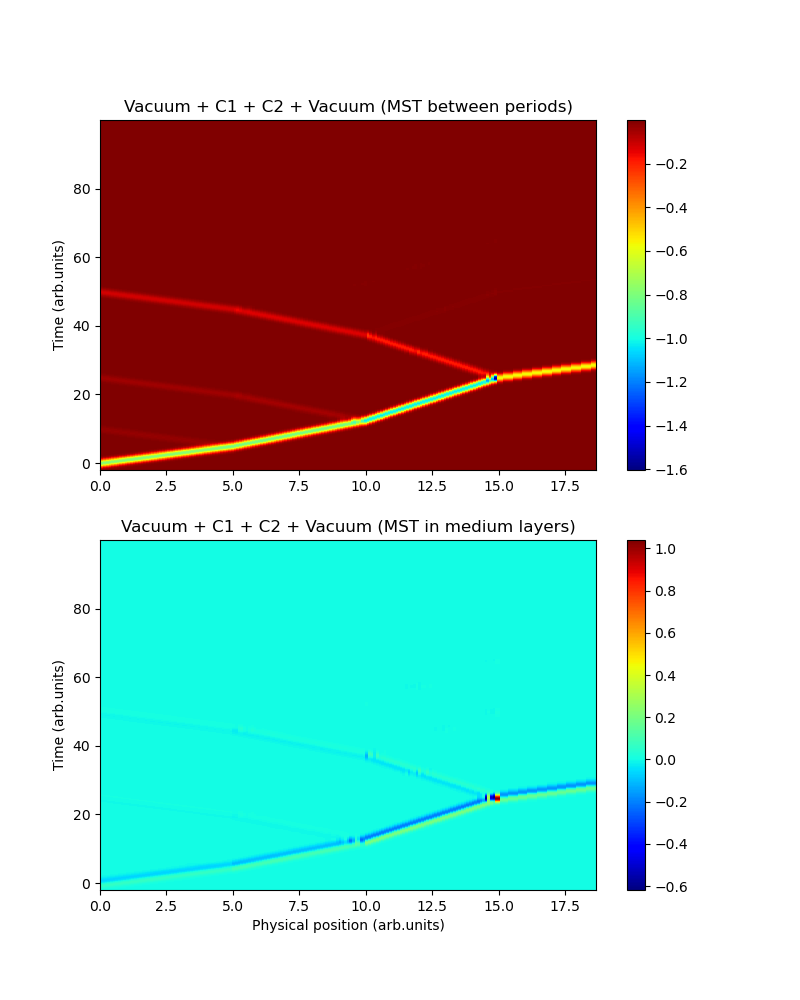

In [10]:
fig, ax = plt.subplots(2,1,figsize=(8,10))
Z=mst2[0::5].T
pc0=ax[0].pcolor(zpos2[0::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax[0].set_xlim([0,zpos2[0::5][-1]])
ax[0].set_title('Vacuum + C1 + C2 + Vacuum (MST between periods)')
#ax[0].set_xlabel('Physical position (arb.units)')
ax[0].set_ylabel('Time (arb.units)')
cbar0 = fig.colorbar(pc0)

Zd=np.diff(Z[:,:],axis=1)
pc1=ax[1].pcolor((zpos2[2::5]+zpos2[3::5])/2, tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
ax[1].set_xlim([0,zpos2[0::5][-1]])
ax[1].set_title('Vacuum + C1 + C2 + Vacuum (MST in medium layers)')
ax[1].set_xlabel('Physical position (arb.units)')
ax[1].set_ylabel('Time (arb.units)')
cbar1 = fig.colorbar(pc1)

#### Impulse over Time

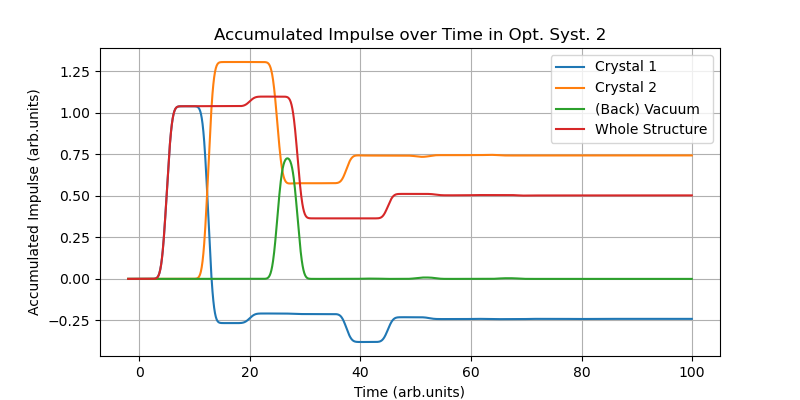

In [52]:
#mlay2=np.diff(mst2[0::5],axis=0)
#edges2 = np.cumsum(nums2)
plt.figure(figsize=(8,4))
#mlay2=np.real(mst2) # [0::5] already just at edges
#plt.plot(tv,np.cumsum(mlay2[edges2[1]]-mlay2[edges2[0]])/momentum_0,label='Crystal 1')
#plt.plot(tv,np.cumsum(mlay2[edges2[2]]-mlay2[edges2[1]])/momentum_0,label='Crystal 2')
#plt.plot(tv,np.cumsum(mlay2[edges2[3]]-mlay2[edges2[2]])/momentum_0,label='(Back) Vacuum')
#plt.plot(tv,np.cumsum(mlay2[edges2[3]]-mlay2[edges2[0]])/momentum_0,label='Whole Structure')
plt.plot(tv,np.cumsum(np.sum(mlay2[edges2[0]:edges2[1]],axis=0))*t_step/momentum_0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(mlay2[edges2[1]:edges2[2]],axis=0))*t_step/momentum_0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(mlay2[edges2[2]:],axis=0))*t_step/momentum_0,label='(Back) Vacuum')
plt.plot(tv,np.cumsum(np.sum(mlay2[edges2[0]:],axis=0))*t_step/momentum_0,label='Whole Structure')
plt.title('Accumulated Impulse over Time in Opt. Syst. 2')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

# Lorentz

## Vacuum + DBR

### Calculation

In [36]:
%%time
# time domain, bulk Lorentz force (z)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d0['gauss'];
aik=(d0['ai_pol_k']/len(kv))[:,2::5] # Only in medium portions
bik=(d0['bi_pol_k']/len(kv))[:,2::5] 

k1,k2=np.meshgrid(kv,kv)

dh0=np.diff(zpos0)[2::5]#*1.1
inds0=d0['n_factors'][2::5]
lor0=1j*np.zeros((len(dh0),len(tv)))

for i in tqdm(range(len(dh0))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1=k1*k2*(1-np.exp(-1j*dh0[i]*(k1-k2)*inds0[i]))
    mat4=mat1.conj()
    mat3=-k1*k2*(1-np.exp(1j*dh0[i]*(k1+k2)*inds0[i]))
    mat2=mat3.conj()
    lor0[i,:]= (inds0[i]**2-1)/2/mu0*np.diag( \
        + ait.conj()@mat1@(ait).T + ait.conj()@mat2@(bit).T\
        + bit.conj()@mat3@(ait).T + bit.conj()@mat4@(bit).T)

lor0=np.real(lor0)#[2::5]

100%|██████████| 90/90 [01:04<00:00,  1.39it/s]

CPU times: user 22min 40s, sys: 23min 18s, total: 45min 58s
Wall time: 1min 4s


In [38]:
momentum_0L = np.cumsum(np.sum(lor0[edges0[0]:],axis=0))[-1]*t_step/2
momentum_0L

0.46611058192390487

### Plots

#### Time, Positions, Magnitude

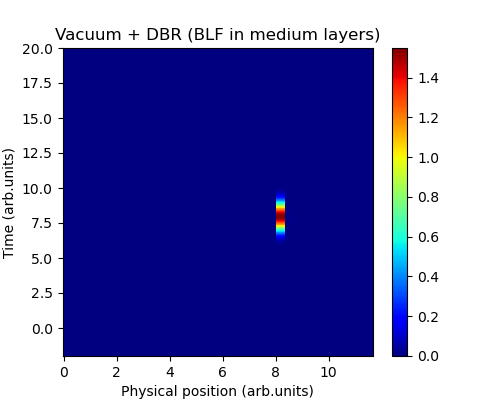

In [4]:
plt.figure(figsize=(5,4))
llay0 = lor0[2::5]
Z=llay0.T
pc0=plt.pcolor(zpos0[2::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
plt.title('Vacuum + DBR (BLF in medium layers)')
plt.xlabel('Physical position (arb.units)')
plt.ylabel('Time (arb.units)')
plt.ylim([-2,20])
cbar0 = fig.colorbar(pc0)

#### Impulse over Time

In [16]:
momentum_0

0.4881339216033709

In [17]:
momentum_0L

0.46611058192390487

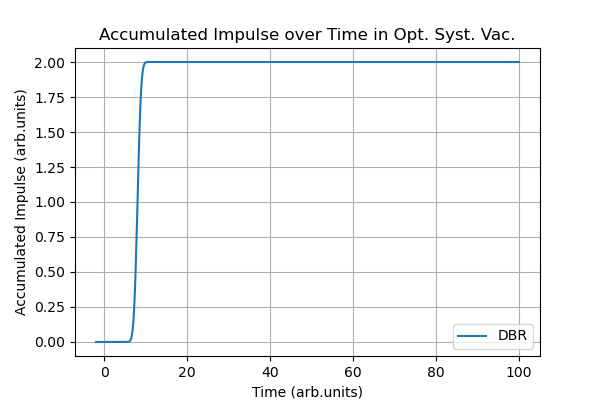

In [18]:
edges0 = np.cumsum(nums0)
p0=momentum_0L
llay0=lor0
plt.figure(figsize=(6,4))
plt.plot(tv,np.cumsum(np.sum(llay0[edges0[0]:],axis=0))*t_step/p0,label='DBR')
plt.title('Accumulated Impulse over Time in Opt. Syst. Vac.')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

## Vacuum + Crystal 1 + Crystal 2 + DBR

### Calculation

In [19]:
%%time
# time domain, bulk Lorentz force (z)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss'];
aik=(d1['ai_pol_k']/len(kv))[:,2::5] # Only in medium portions
bik=(d1['bi_pol_k']/len(kv))[:,2::5]

k2,k1=np.meshgrid(kv,kv)

dh1=np.diff(zpos1)[2::5]
inds1=d1['n_factors'][2::5]
lor1=1j*np.zeros((len(dh1),len(tv)))

for i in tqdm(range(len(dh1))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1=-k1*k2*(1-np.exp(-1j*dh1[i]*(k1-k2)*inds1[i]))
    mat4=mat1.conj()
    mat3=k1*k2*(1-np.exp(1j*dh1[i]*(k1+k2)*inds1[i]))
    mat2=mat3.conj()
    lor1[i,:]= -(inds1[i]**2-1)/2/mu0**2*np.diag( \
        + ait.conj()@mat1@(ait).T + ait.conj()@mat2@(bit).T\
        + bit.conj()@mat3@(ait).T + bit.conj()@mat4@(bit).T)

lor1=np.real(lor1)#[:,2::5]

100%|██████████| 160/160 [01:51<00:00,  1.43it/s]

CPU times: user 39min 13s, sys: 40min 5s, total: 1h 19min 18s
Wall time: 1min 52s


### Plots

#### Time, Positions, Magnitude

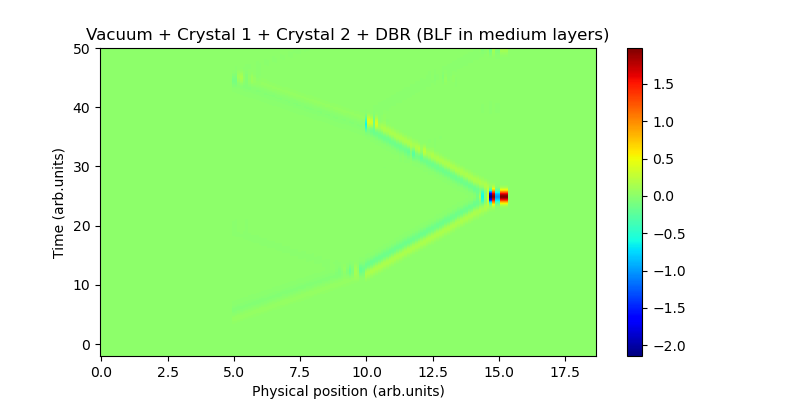

In [17]:
plt.figure(figsize=(8,4))
Z=lor1[2::5].T
pc0=plt.pcolor(zpos1[2::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
plt.title('Vacuum + Crystal 1 + Crystal 2 + DBR (BLF in medium layers)')
plt.xlabel('Physical position (arb.units)')
plt.ylabel('Time (arb.units)')
plt.ylim([-2,50])
cbar0 = fig.colorbar(pc0)

#### Impulse over Time

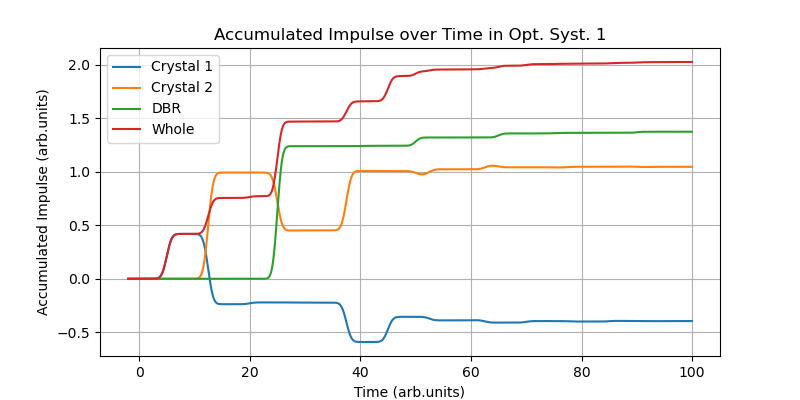

In [20]:
llay1=lor1#[2::5]
edges1 = np.cumsum(nums1)
plt.figure(figsize=(8,4))
p0 = momentum_0L
plt.plot(tv,np.cumsum(np.sum(llay1[edges1[0]:edges1[1]],axis=0))*t_step/p0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(llay1[edges1[1]:edges1[2]],axis=0))*t_step/p0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(llay1[edges1[2]:edges1[3]],axis=0))*t_step/p0,label='DBR')
plt.plot(tv,np.cumsum(np.sum(llay1[edges1[0]:],axis=0))*t_step/p0,label='Whole')
plt.title('Accumulated Impulse over Time in Opt. Syst. 1')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

## Vacuum + Crystal 1 + Crystal 2 + Vacuum

### Calculation

In [21]:
%%time
# time domain, bulk Lorentz force (z)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d2['gauss'];
aik=(d2['ai_pol_k']/len(kv))[:,2::5] # Only in medium portions
bik=(d2['bi_pol_k']/len(kv))[:,2::5]

k2,k1=np.meshgrid(kv,kv)

dh2=np.diff(zpos2)[2::5]
inds2=d2['n_factors'][2::5]
lor2=1j*np.zeros((len(dh2),len(tv)))
for i in tqdm(range(len(dh2))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1=-k1*k2*(1-np.exp(-1j*dh2[i]*(k1-k2)*inds2[i]))
    mat4=mat1.conj()
    mat3=k1*k2*(1-np.exp(1j*dh2[i]*(k1+k2)*inds2[i]))
    mat2=mat3.conj()
    lor2[i,:]= -(inds2[i]**2-1)/2/mu0**2*np.diag( \
        + ait.conj()@mat1@(ait).T + ait.conj()@mat2@(bit).T\
        + bit.conj()@mat3@(ait).T + bit.conj()@mat4@(bit).T)

lor2=np.real(lor2)#[:,2::5]

100%|██████████| 160/160 [01:53<00:00,  1.42it/s]

CPU times: user 39min 11s, sys: 41min 3s, total: 1h 20min 15s
Wall time: 1min 53s


### Plots

#### Time, Positions, Magnitude

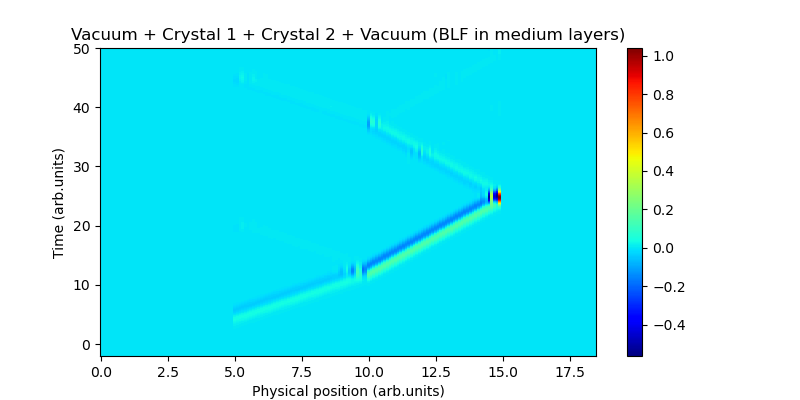

In [9]:
plt.figure(figsize=(8,4))
Z=lor2[2::5].T
pc0=plt.pcolor(zpos2[2::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
plt.title('Vacuum + Crystal 1 + Crystal 2 + Vacuum (BLF in medium layers)')
plt.xlabel('Physical position (arb.units)')
plt.ylabel('Time (arb.units)')
plt.ylim([-2,50])
cbar0 = fig.colorbar(pc0)

#### Impulse over Time

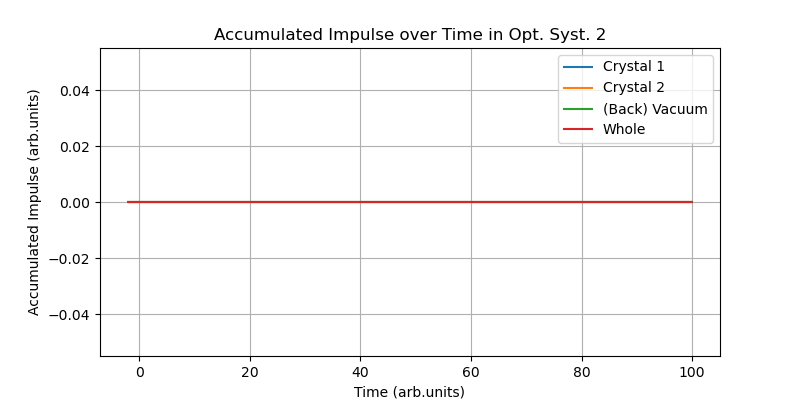

In [59]:
llay2=lor2[2::5]
edges2 = np.cumsum(nums2)
plt.figure(figsize=(8,4))
p0 = momentum_0L
plt.plot(tv,np.cumsum(np.sum(llay2[edges2[0]:edges2[1]],axis=0))*t_step/p0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(llay2[edges2[1]:edges2[2]],axis=0))*t_step/p0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(llay2[edges2[2]:],axis=0))*t_step/p0,label='(Back) Vacuum')
plt.plot(tv,np.cumsum(np.sum(llay2[edges2[0]:],axis=0))*t_step/p0,label='Whole')
plt.title('Accumulated Impulse over Time in Opt. Syst. 2')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

# Compare

In [22]:
def impulse(forces_t_pos,t_values,indices,t_step):
    return np.cumsum(np.sum(forces_t_pos[indices[0]:indices[1]],axis=0))*t_step

def impulses(forces_t_pos,t_values,edges,t_step):
    imp = []
    for i in range(len(edges)-1):
        imp+=[impulse(forces_t_pos,t_values,[edges[i],edges[i+1]],t_step)]
    imp+=[impulse(forces_t_pos,t_values,[edges[0],edges[-1]],t_step)]
    return imp

## Vacuum + DBR

### Poynting

#### Calculation

In [25]:
%%time
# time domain, Poynting (z) at positions (not integral yet - need to take differences around periods)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d0['gauss'];
aik=(d0['ai_pol_k']/len(kv))[:,:-1] # [:,0::5]
bik=(d0['bi_pol_k']/len(kv))[:,:-1]

k2,k1=np.meshgrid(kv,kv)
inds0=d0['n_factors'][:-1]
dh0=np.diff(zpos0)
poyn0=1j*np.zeros((len(dh0),len(tv)))
for i in tqdm(range(len(dh0))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1 = 1-np.exp(1j*(k1-k2)*inds0[i]*dh0[i])
    mat2 = (k1-k2)/(k1+k2)*(1-np.exp(1j*(k1+k2)*inds0[i]*dh0[i]))
    mat3 = -mat2.conj()
    mat4 = -mat1.conj()
    poyn0[i,:]= 1/mu0*np.diag(ait@mat1@(ait.conj()).T - ait@mat2@(bit.conj()).T  \
                                     - bit@mat3@(ait.conj()).T + bit@mat4@(bit.conj()).T)

poyn0=np.real(poyn0)

 21%|██        | 95/450 [01:07<04:11,  1.41it/s]


KeyboardInterrupt: 

#### Plots

##### Time, Positions, Magnitude

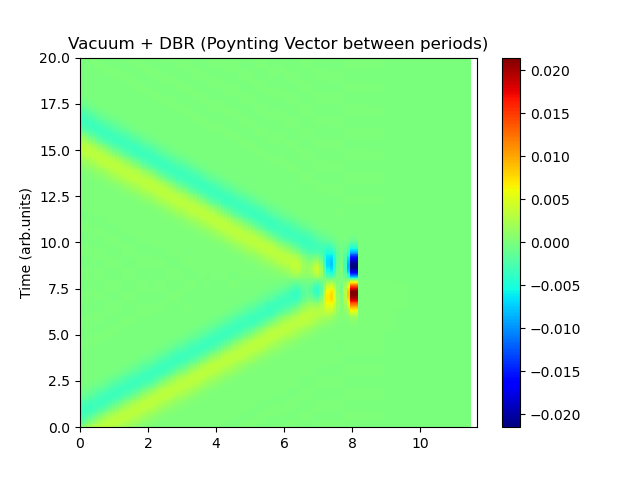

In [69]:
fig, ax = plt.subplots(1,1)
play0=poyn0[2::5]+poyn0[0::5]+poyn0[4::5]
Z=play0.T
pc0=ax.pcolor(zpos0[0::5][:-1], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax.set_xlim([0,zpos0[0::5][-1]])
ax.set_ylim([0,20])
ax.set_title('Vacuum + DBR (Poynting Vector between periods)')
#ax[0].set_xlabel('Physical position (arb.units)')
ax.set_ylabel('Time (arb.units)')
cbar0 = fig.colorbar(pc0)

#Zd=np.diff(Z[:,:],axis=1) # np.real(poyn2b[4::5]-poyn2b[1::5]).T #np.diff(Z[:,:],axis=1)
#pc1=ax[1].pcolor((zpos0[2::5]+zpos0[3::5])/2, tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
#ax[1].set_xlim([0,((zpos0[2::5]+zpos0[3::5])/2)[-1]])
#ax[1].set_title('Vacuum + DBR (Poynting Vector in medium layers)')
#ax[1].set_xlabel('Physical position (arb.units)')
#ax[1].set_ylabel('Time (arb.units)')
#cbar1 = fig.colorbar(pc1)

##### Impulse over Time

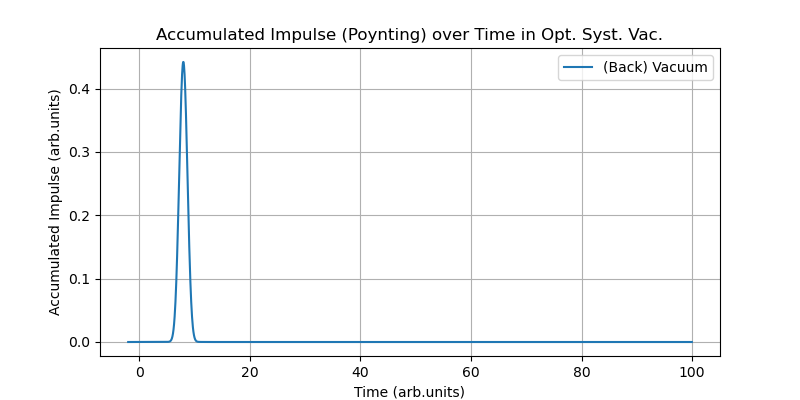

In [63]:
play0=poyn0[2::5]+poyn0[0::5]+poyn0[4::5]
edges0 = np.cumsum(nums0)
plt.figure(figsize=(8,4))
p0 = 1
plt.plot(tv,np.cumsum(np.sum(play0[edges0[0]:],axis=0))/p0,label='(Back) Vacuum')
plt.title('Accumulated Impulse (Poynting) over Time in Opt. Syst. Vac.')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

### Whole

In [27]:
play0=poyn0[2::5]+poyn0[0::5]+poyn0[4::5]
llay0=lor0#[2::5]
mlay0=np.diff(mst0,axis=0)#[0::5]
imst0 = impulses(mlay0,tv,edges0,t_step)
ilor0 = impulses(llay0,tv,edges0,t_step)
ipv0 = 0#impulses(play0,tv,edges0,t_step)

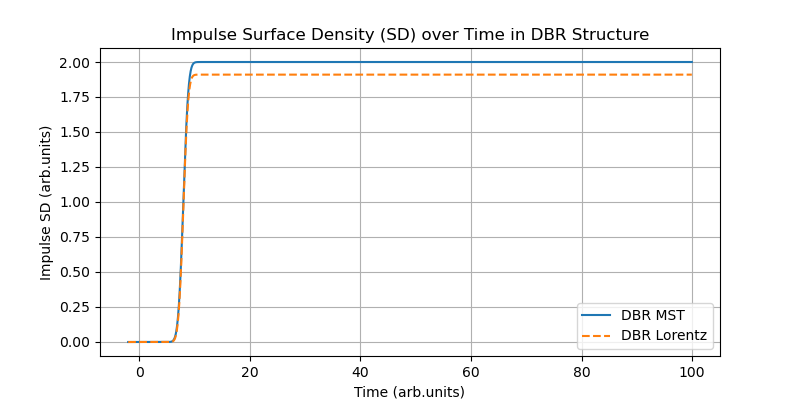

In [29]:
i = 0
plt.figure(figsize=(8,4))
p0 = momentum_0
int_regions = ['DBR Structure','Whole System']
plt.plot(tv,(imst0[i]-1/c**2*ipv0)/p0,label='DBR MST')
plt.plot(tv,ilor0[i]/p0,ls='--',label='DBR Lorentz')
#plt.axvline(ts[100],lw=15,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
#plt.axvline(ts[220],lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
#plt.axvline(ts[420],lw=20,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
#plt.axvline(31,lw=13,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
#plt.axvline(36.8,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
plt.ylabel('Impulse SD (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

## Vacuum + Crystal 1 + Crystal 2 + DBR

### Poynting

#### Calculation

In [36]:
%%time
# time domain, Poynting (z) at positions (not integral yet - need to take differences around periods)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss'];
aik=(d1['ai_pol_k']/len(kv))[:,:-1] # [:,0::5]
bik=(d1['bi_pol_k']/len(kv))[:,:-1]

k2,k1=np.meshgrid(kv,kv)
inds1=d1['n_factors'][:-1]
dh1=np.diff(zpos1)
poyn1=1j*np.zeros((len(dh1),len(tv)))
for i in tqdm(range(len(dh1))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1 = 1-np.exp(1j*(k1-k2)*inds1[i]*dh1[i])
    mat2 = (k1-k2)/(k1+k2)*(1-np.exp(1j*(k1+k2)*inds1[i]*dh1[i]))
    mat3 = -mat2.conj()
    mat4 = -mat1.conj()
    poyn1[i,:]= 1/mu0*np.diag(ait@mat1@(ait.conj()).T - ait@mat2@(bit.conj()).T  \
                                     - bit@mat3@(ait.conj()).T + bit@mat4@(bit.conj()).T)

poyn1=np.real(poyn1)
boundaries1 = np.cumsum(nums1*hs1)

100%|██████████| 800/800 [05:14<00:00,  2.54it/s]


NameError: name 'play1' is not defined

#### Plots

##### Time, Positions, Magnitude

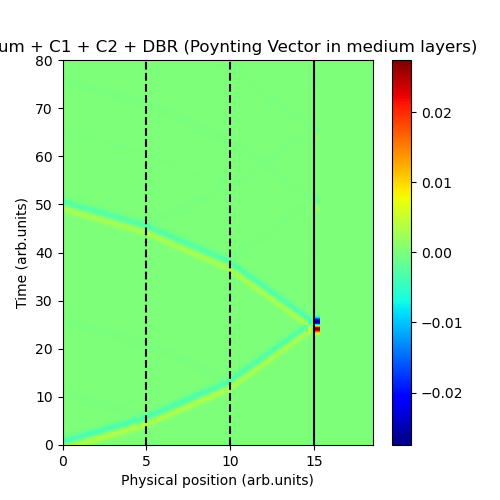

In [62]:
boundaries1 = np.cumsum(nums1*hs1)
fig, ax = plt.subplots(1,1,figsize=(5,5))
start = 2
play1=poyn1[2::5]+poyn1[0::5]+poyn1[4::5]
Z=play1.T #(np.cumsum(play1[start::5],axis=1)).T 
pc0=ax.pcolor(zpos1[start::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax.set_xlim([0,zpos1[start::5][-1]]) #[0::5]
ax.set_ylim([0,80])
ax.set_title('Vacuum + C1 + C2 + DBR (Poynting Vector in medium layers)')
ax.set_xlabel('Physical position (arb.units)')
ax.set_ylabel('Time (arb.units)')
for i in range(len(boundaries1)-2):
    ax.axvline(boundaries1[i],c='k',ls='--')
ax.axvline(boundaries1[-2],c='k')
cbar0 = fig.colorbar(pc0)

#Zd=(play1[start::5]np.diff(Z[:,:],axis=1)
#pc1=ax[1].pcolor(((zpos1[2::5]+zpos1[3::5])/2)[:-1], tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
#ax[1].set_xlim([0,(((zpos1[2::5]+zpos1[3::5])/2)[:-1])[-1]])
#ax[1].set_title('Vacuum + C1 + C2 + DBR (Poynting Vector in medium layers)')
#ax[1].set_xlabel('Physical position (arb.units)')
#ax[1].set_ylabel('Time (arb.units)')
#cbar1 = fig.colorbar(pc1)

##### Impulse over Time

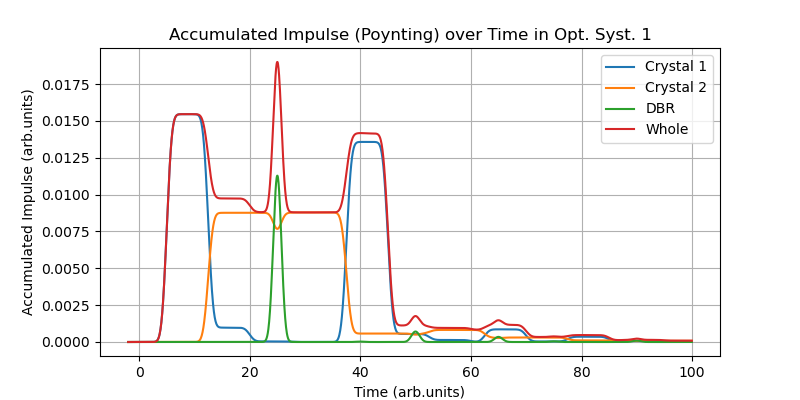

In [64]:
play1=poyn1[0::5]+poyn1[2::5]+poyn1[4::5] #np.real(poyn2a[4::5]-poyn2a[1::5]) #np.real(poyn2)-
edges1 = np.cumsum(nums1)
plt.figure(figsize=(8,4))
p0 = momentum_0
plt.plot(tv,np.cumsum(np.sum(play1[edges1[0]:edges1[1]],axis=0))*t_step/p0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(play1[edges1[1]:edges1[2]],axis=0))*t_step/p0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(play1[edges1[2]:],axis=0))*t_step/p0,label='DBR')
plt.plot(tv,np.cumsum(np.sum(play1[edges1[0]:],axis=0))*t_step/p0,label='Whole')
plt.title('Accumulated Impulse (Poynting) over Time in Opt. Syst. 1')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

### Whole

In [14]:
startm = 0
startl = 2
startp = 2
mlay1 = np.diff(mst1[startm::5],axis=0)
llay1 = lor1[startl::5]
play1=poyn1[0::5]+poyn1[2::5]+poyn1[4::5]
imst1 = impulses(mlay1,tv,edges1,t_step)
ilor1 = impulses(llay1,tv,edges1,t_step)
ipv1 = impulses(play1,tv,edges1,t_step)

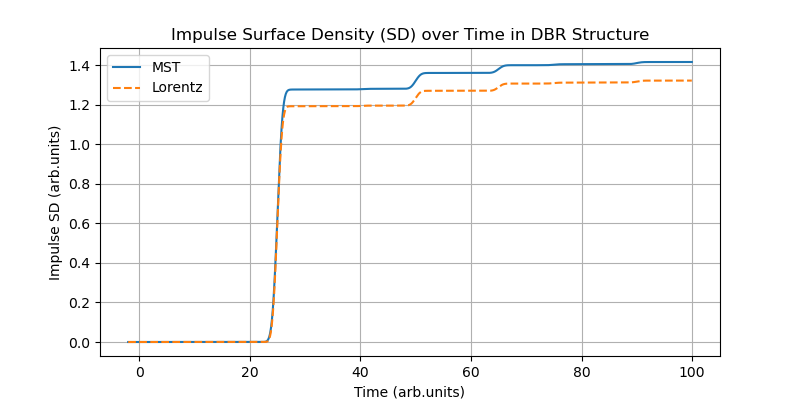

In [15]:
i = 2
plt.figure(figsize=(8,4))
p0 = momentum_0
int_regions = ['Crystal 1','Crystal 2','DBR Structure','Whole System']
plt.plot(tv,np.cumsum(np.sum((mlay1-1/c**2*play1)[edges1[-2]:],axis=0))*t_step/p0,label='MST')
plt.plot(tv,np.cumsum(np.sum(llay1[edges1[-2]:],axis=0))*t_step/p0,ls='--',label='Lorentz')
plt.ylabel('Impulse SD (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

## Vacuum + Crystal 1 + Crystal 2 + Vacuum

### Poynting

#### Calculation

In [46]:
%%time
# time domain, Poynting (z) at positions (not integral yet - need to take differences around periods)

c, eps0, mu0=1, 1, 1
mt=np.exp(-1j * np.outer(tv,kv) * c)*d2['gauss'];
aik=(d2['ai_pol_k']/len(kv))[:,:-1] # [:,0::5]
bik=(d2['bi_pol_k']/len(kv))[:,:-1]

k2,k1=np.meshgrid(kv,kv)
inds2=d2['n_factors'][:-1]
dh2=np.diff(zpos2)
poyn2=1j*np.zeros((len(dh2),len(tv)))
for i in tqdm(range(len(dh2))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1 = 1-np.exp(1j*(k1-k2)*inds2[i]*dh2[i])
    mat2 = (k1-k2)/(k1+k2)*(1-np.exp(1j*(k1+k2)*inds2[i]*dh2[i]))
    mat3 = -mat2.conj()
    mat4 = -mat1.conj()
    poyn2[i,:]= 1/mu0*np.diag(ait@mat1@(ait.conj()).T - ait@mat2@(bit.conj()).T  \
                                     - bit@mat3@(ait.conj()).T + bit@mat4@(bit.conj()).T)

poyn2=np.real(poyn2)

100%|██████████| 800/800 [05:17<00:00,  2.52it/s]

CPU times: user 1h 44min 7s, sys: 2h 27min 5s, total: 4h 11min 13s
Wall time: 5min 17s


#### Plots

##### Time, Positions, Magnitude

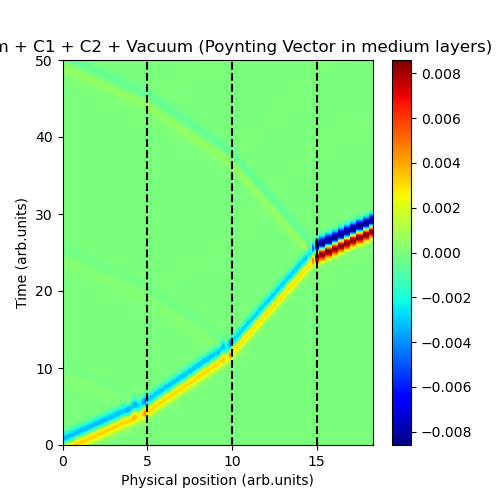

In [81]:
boundaries2 = np.cumsum(nums2*hs2)
fig, ax = plt.subplots(1,1,figsize=(5,5))
play2=poyn2[2::5]+poyn2[0::5]+poyn2[4::5]
start = 2
Z=play2.T
pc0=ax.pcolor(zpos2[start::5], tv, Z,  vmax=Z.max(), vmin=Z.min(), cmap=plt.cm.jet)
ax.set_xlim([0,zpos2[start::5][-1]]) #[0::5]
ax.set_ylim([0,50])
ax.set_title('Vacuum + C1 + C2 + Vacuum (Poynting Vector in medium layers)')
ax.set_xlabel('Physical position (arb.units)')
ax.set_ylabel('Time (arb.units)')
for i in range(len(boundaries1)-1):
    ax.axvline(boundaries2[i],c='k',ls='--')
#ax.axvline(boundaries2[-2],c='k')
cbar0 = fig.colorbar(pc0)

#Zd=(play1[start::5]np.diff(Z[:,:],axis=1)
#pc1=ax[1].pcolor(((zpos1[2::5]+zpos1[3::5])/2)[:-1], tv, Zd,  vmax=Zd.max(), vmin=Zd.min(), cmap=plt.cm.jet)
#ax[1].set_xlim([0,(((zpos1[2::5]+zpos1[3::5])/2)[:-1])[-1]])
#ax[1].set_title('Vacuum + C1 + C2 + DBR (Poynting Vector in medium layers)')
#ax[1].set_xlabel('Physical position (arb.units)')
#ax[1].set_ylabel('Time (arb.units)')
#cbar1 = fig.colorbar(pc1)

##### Impulse over Time

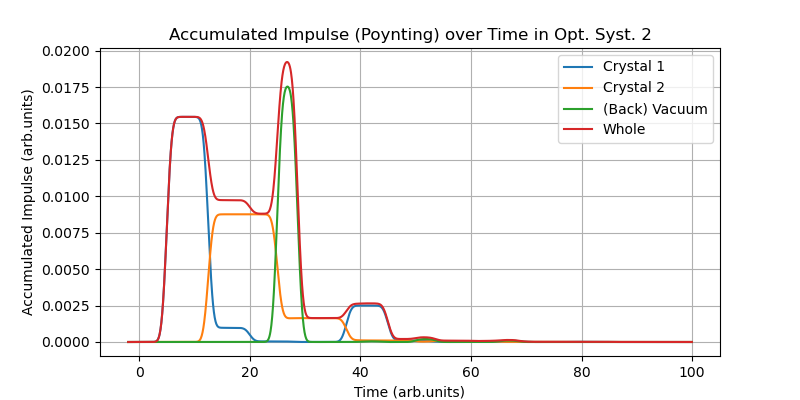

In [83]:
play2=poyn2[2::5]+poyn2[0::5]+poyn2[4::5]
edges2 = np.cumsum(nums2)
plt.figure(figsize=(8,4))
p0 = momentum_0
plt.plot(tv,np.cumsum(np.sum(play2[edges2[0]:edges2[1]],axis=0))*t_step/p0,label='Crystal 1')
plt.plot(tv,np.cumsum(np.sum(play2[edges2[1]:edges2[2]],axis=0))*t_step/p0,label='Crystal 2')
plt.plot(tv,np.cumsum(np.sum(play2[edges2[2]:],axis=0))*t_step/p0,label='(Back) Vacuum')
plt.plot(tv,np.cumsum(np.sum(play2[edges2[0]:],axis=0))*t_step/p0,label='Whole')
plt.title('Accumulated Impulse (Poynting) over Time in Opt. Syst. 2')
plt.xlabel('Time (arb.units)')
plt.ylabel('Accumulated Impulse (arb.units)')
plt.grid()
plt.legend()
plt.show()

### Whole

In [17]:
startm = 0 
startl = 2
startp = 2
mlay2 = np.diff(mst2[startm::5],axis=0)
llay2 = lor2[startl::5]
play2=poyn2[0::5]+poyn2[2::5]+poyn2[4::5]
imst2 = impulses(mlay2,tv,edges2,t_step)
ilor2 = impulses(llay2,tv,edges2,t_step)
ipv2 = impulses(play2[startp::5],tv,edges2,t_step)

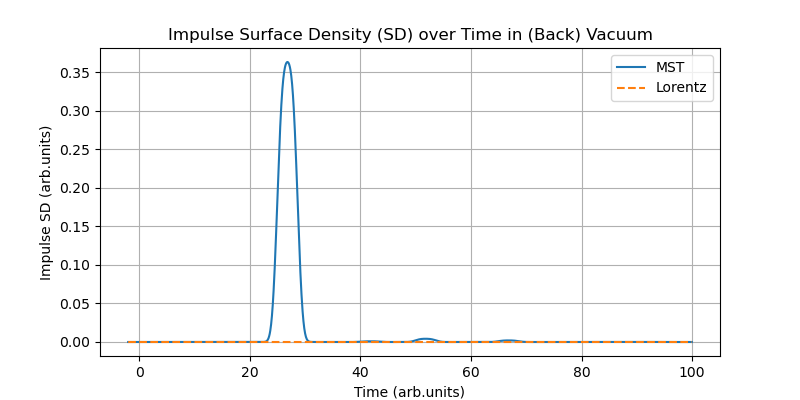

In [18]:
i = 2
plt.figure(figsize=(8,4))
p0 = momentum_0
int_regions = ['Crystal 1','Crystal 2','(Back) Vacuum','Whole System']
plt.plot(tv,(imst2[i]-ipv2[i])/p0,label='MST')
plt.plot(tv,ilor2[i]/p0,ls='--',label='Lorentz')
plt.ylabel('Impulse SD (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

## Combined

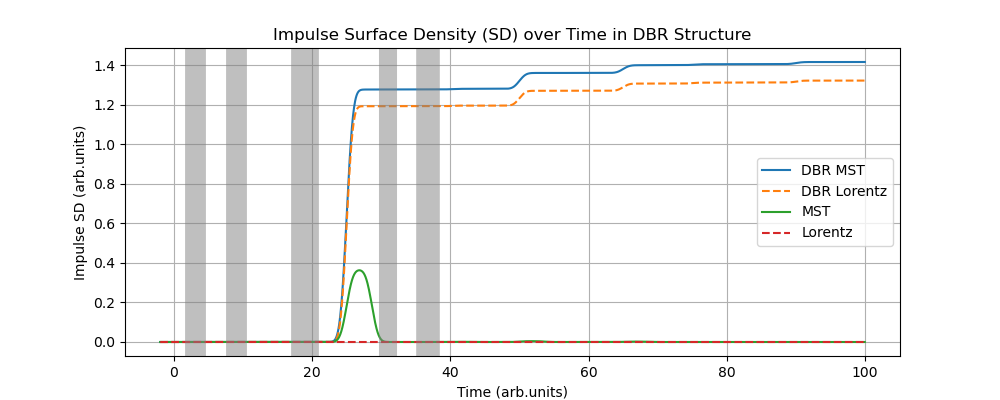

In [99]:
i = 2
plt.figure(figsize=(10,4))
int_regions = ['Crystal 1','Crystal 2','DBR Structure','Whole System']
p0 = momentum_0
plt.plot(tv,(imst1[i]+ipv1[i])/p0,label='DBR MST')
plt.plot(tv,(ilor1[i])/p0,ls='--',label='DBR Lorentz')
plt.plot(tv,(imst2[i]+ipv2[i])/p0,label='MST')
plt.plot(tv,(ilor2[i])/p0,ls='--',label='Lorentz')
plt.axvline(tv[100],lw=15,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
plt.axvline(tv[220],lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
plt.axvline(tv[420],lw=20,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
plt.axvline(31,lw=13,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
plt.axvline(36.8,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
plt.ylabel('Impulse SD (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('Impulse Surface Density (SD) over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

## Stacked

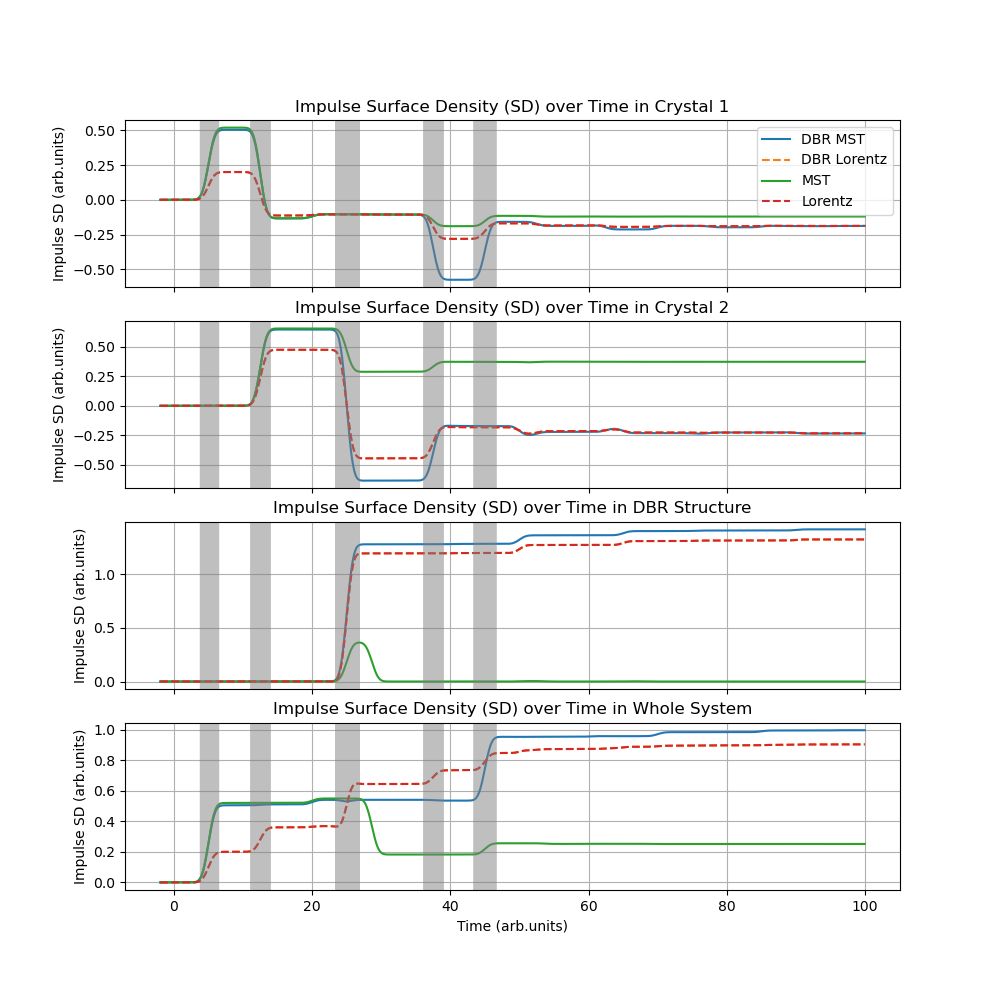

In [89]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
int_regions = ['Crystal 1','Crystal 2','DBR Structure','Whole System']
p0=momentum_0
for i in range(len(int_regions)):
    axs[i].set_title('Impulse Surface Density (SD) over Time in '+int_regions[i])
    axs[i].set_ylabel('Impulse SD (arb.units)')
    axs[i].plot(tv,(imst1[i]-ipv1[i])/p0,label='DBR MST')
    axs[i].plot(tv,(ilor1[i])/p0,ls='--',label='DBR Lorentz')
    axs[i].plot(tv,(imst2[i]-ipv2[i])/p0,label='MST')
    axs[i].plot(tv,(ilor1[i])/p0,ls='--',label='Lorentz')
    axs[i].axvline(5,lw=14,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
    axs[i].axvline(12.5,lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
    axs[i].axvline(25,lw=18,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
    axs[i].axvline(37.4,lw=15,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
    axs[i].axvline(45,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
    axs[i].grid()
    if i == 0:
        axs[i].legend() #(loc='upper right')
    if i == 3:
        axs[i].set_xlabel('Time (arb.units)')
plt.show()

# For Report

## Functions

In [21]:
colors = ['b','orange','g']
colors_med = ['blue'] # For plotting the crystals
colors_med1 = ['blue','red','green']
colors_med2 = ['blue','red','green','blue']

def plot_amps(ai,bi,xvals,time,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers*h_DBR],top_ys,bottom_ys,color='gray',alpha=0.2)
    #plt.plot(xvals,np.abs(ai)**2, label='|a|^2',c=cols[0])
    #plt.plot(xvals,np.abs(bi)**2, label='|b|^2',c=cols[1])
    #plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2',c=cols[2])
    plt.title('Optical System 2')#f'Intensity Across Layers t = {time:.2f} arb. units')
    plt.xlabel('Position (arb. units)') # A layer starts at the vacuum half before the medium portion
    #plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    #plt.legend()
    plt.grid()
    plt.show()

def amps3times(a_t_pos,b_t_pos,xvals,ts3,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,np.abs(a_t_pos[ts3[0]])**2, label='|a|^2',c=cols[0])# t = {t_vals[t3d[0]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[0]])**2, label='|b|^2',c=cols[1])
    plt.plot(xvals,np.abs(a_t_pos[ts3[0]]+b_t_pos[ts3[0]])**2, label='|a+b|^2',c=cols[2])
    
    plt.plot(xvals,np.abs(a_t_pos[ts3[1]])**2, ls = '-.',c=cols[0])#, label=f'|a|^2 t = {t_vals[t3d[1]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[1]])**2, ls = '-.',c=cols[1])#, label='|b|^2')
    plt.plot(xvals,np.abs(a_t_pos[ts3[1]]+b_t_pos[ts3[1]])**2, ls = '-.',c=cols[2])#, c=colors[2], label='|a+b|^2')
    
    plt.plot(xvals,np.abs(a_t_pos[ts3[2]])**2, ls = '--',c=cols[0])#, label=f'|a|^2 t = {t_vals[t3d[2]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[2]])**2, ls = '--',c=cols[1])#, label='|b|^2')
    plt.plot(xvals,np.abs(a_t_pos[ts3[2]]+b_t_pos[ts3[2]])**2, ls = '--',c=cols[2])#, c=colors[2], label='|a+b|^2')
    
    plt.title(f'Intensity Across Periods')
    plt.xlabel('Position (arb. units)') # A layer starts at the vacuum half before the medium portion
    plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()
    plt.grid()
    plt.show()

#np.cumsum(f_dens_pos.T,axis=0)
def plot_mstimps(mimp1,mimp2,xvals,time,num_elements,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Impulse Surface Densities (arb. units)') #Force/Impulse SD
    plt.title(f'(MST) Z-Impulse Surface Densities in Medium Layers t = {time:.2f} arb. units') #Z-Force Surface Densities (SD)
    plt.plot(xvals,mimp1,label='DBR',c=cols[0])
    plt.plot(xvals,mimp2,label='No DBR',c=cols[1])
    #plt.plot(xvals,impsd_mst_pos,c='purple')#,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    #np.cumsum(f_dens_pos.T,axis=0)
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()#loc='upper left')
    plt.grid()
    plt.plot()

def plot_mstforcez(fdp1,fdp2,fdp3,xvals,time1,time2,time3,num_elements,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Momentum Flux (arb. units)') #Force/Impulse SD
    plt.title(f'(MST) Z-Momentum Flux in Medium Layers') #Z-Force Surface Densities (SD)
    plt.plot(xvals,fdp1,label=f't = {time1:.2f} arb. units')
    plt.plot(xvals,fdp2,label=f't = {time2:.2f} arb. units')
    plt.plot(xvals,fdp3,label=f't = {time3:.2f} arb. units')
    #plt.plot(xvals,impsd_mst_pos,c='purple')#,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    #np.cumsum(f_dens_pos.T,axis=0)
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()#loc='upper left')
    plt.grid()
    plt.plot()

#np.cumsum(layerforces.T,axis=0)
def plot_lorentz1imps(layerforces1,layerforces2,xvals,time,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Z-Impulse Surface Densities in Medium Layers t = {time:.2f} time units')
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Impulse Surface Density (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,layerforces1,label='DBR',c=cols[0])
    plt.plot(xvals,layerforces2,label='No DBR',c=cols[1])
    #plt.plot(xvals,impsd_lor_pos,c=cols[1])#label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.grid()
    plt.legend()#loc='upper left')
    plt.show()

def plot_lorentzforcez1(layerforces1,layerforces2,layerforces3,xvals,time1,time2,time3,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Force Surface Densities in Medium Layers')
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Force Surface Density (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,layerforces1,label=f't = {time1:.2f} arb. units')
    plt.plot(xvals,layerforces2,label=f't = {time2:.2f} arb. units')
    plt.plot(xvals,layerforces3,label=f't = {time3:.2f} arb. units')
    #plt.plot(xvals,impsd_lor_pos,c=cols[1])#label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.grid()
    plt.legend()#loc='upper left')
    plt.show()

## Plots

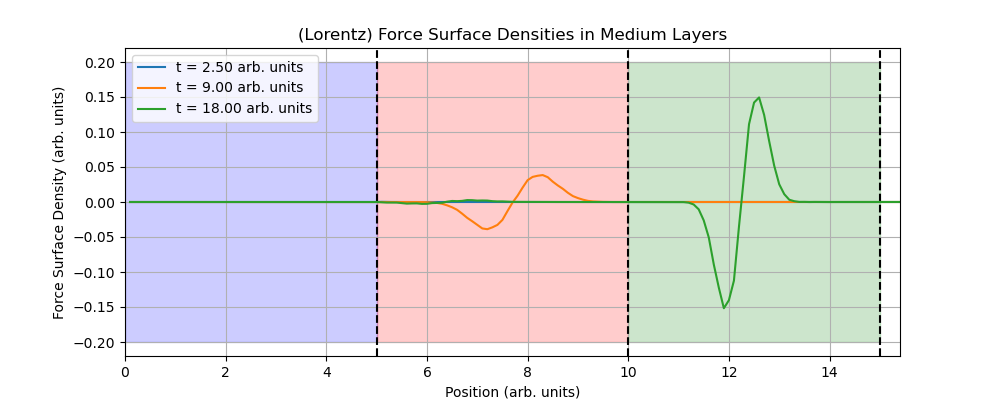

CPU times: user 3.24 s, sys: 4.02 s, total: 7.26 s
Wall time: 331 ms


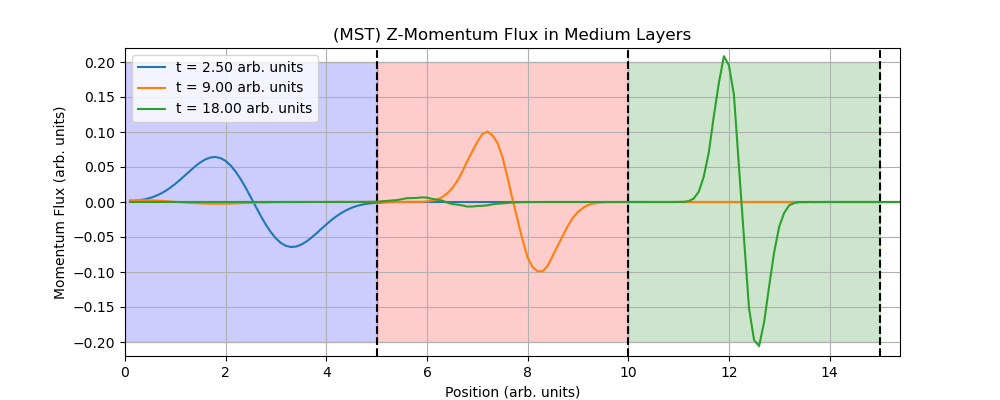

In [22]:
%%time
#time domain, intensity
c=1;
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss']
norm = np.sum(np.abs(mt[0]))
a_k = d1['ai_pol_k']#[:,0::5]
b_k = d1['bi_pol_k']#[:,0::5]
a_t=((mt@a_k)/norm)[:,0::5]
b_t=((mt@b_k)/norm)[:,0::5]
pos = zpos1[0::5]
boundaries = np.cumsum(d1['nums'])*d1['hs']
nums = d1['nums']
hs = d1['hs']

ta = 80+10 # 2 seconds
tb = 220 # 9 seconds
tc = 400 # 18 seconds
tdbr = 560 # 26 seconds
#t=180

#plot_amps(a_t[t],b_t[t],pos,tv[t],nums*hs,hs[-1],n_DBR_pers=0,cols=colors,cols_med=colors_med2)
ts3 = [ta,tb,tc]
#amps3times(a_t,b_t,pos,ts3,nums[:-1]*hs[:-1],hs[-1],n_DBR_pers=1,cols_med=colors_med1)
t=-1
#np.cumsum(llay1.T,axis=0)[t]
LF = lor1[2::5].T
plot_lorentzforcez1(LF[ta],LF[tb],LF[tc],pos[1:],tv[ta],tv[tb],tv[tc],nums[:-1]*hs[:-1],hs[-1],n_DBR_pers=0,
                    cols_med=colors_med1,top_y=0.2,bottom_y=-0.2)
MST = (np.diff(-mst1[0::5].T))
plot_mstforcez(MST[ta],MST[tb],MST[tc],pos[1:],tv[ta],tv[tb],tv[tc],nums[:-1]*hs[:-1],n_DBR_pers=0,cols=colors,cols_med=colors_med1,
            top_y=.2,bottom_y=-.2)

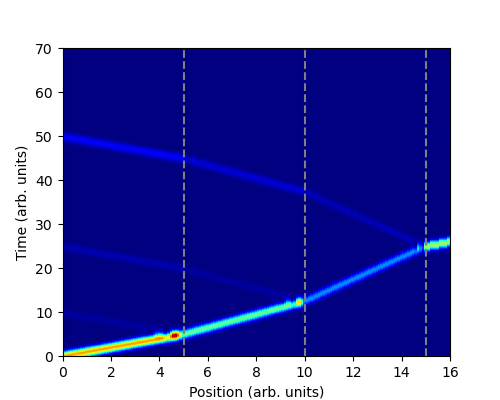

CPU times: user 3.32 s, sys: 2.65 s, total: 5.97 s
Wall time: 1.37 s


In [17]:
%%time
#time domain, intensity
c=1;
mt=np.exp(-1j * np.outer(tv,kv) * c)*d2['gauss']
a_s = d2['ai_pol_k'][:,0::5]
b_s = d2['bi_pol_k'][:,0::5]
pos = zpos2[0::5]

plt.figure(figsize=(5,4))
Z=np.abs(mt@(a_s+b_s))**2
plt.pcolor(pos,tv,Z,  vmax=abs(Z).max(), vmin=0, cmap='jet')
plt.xlim([0,16])#pos[-1]
plt.ylim([0,70])
plt.axvline(boundaries2[0],ls='--',c='gray')
plt.axvline(boundaries2[1],ls='--',c='gray')
plt.axvline(boundaries2[2],c='gray',ls='--')#lw=3)#,
#plt.title('Pulse Intensity Vacuum + DBR')
plt.ylabel('Time (arb. units)')
plt.xlabel('Position (arb. units)')
plt.show()

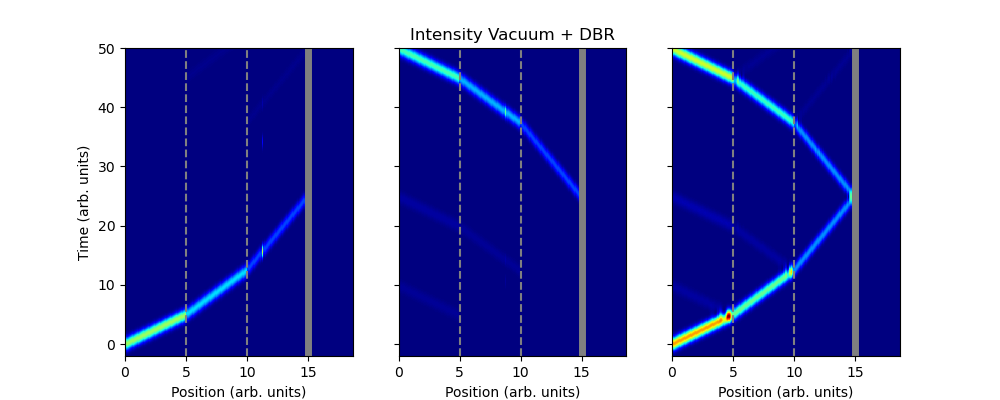

CPU times: user 28.8 s, sys: 8.67 s, total: 37.4 s
Wall time: 22 s


In [57]:
%%time
#time domain, intensity
c=1;
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss'];
a_s = d1['ai_pol_k']#[:,0::5]
b_s = d1['bi_pol_k']#[:,0::5]
pos = zpos1#[0::5]
xlim = pos[-1]
ylim = 50
boundaries = np.cumsum(d1['nums'])*d1['hs']
width = 5

fig, ax = plt.subplots(1,3,figsize=(10,4),sharey=True)
Z=np.abs(mt@(a_s))**2
ax[0].pcolor(pos,tv,Z,  vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
#ax[0].set_title('a Intensity Vacuum + DBR')
ax[0].set_xlim([0,xlim])
ax[0].set_ylim([-2,ylim])
ax[0].set_xlabel('Position (arb. units)')
ax[0].set_ylabel('Time (arb. units)')
for i in range(len(boundaries)-1):
    ax[0].axvline(boundaries[i],ls='--',c='gray')
ax[0].axvline(boundaries[-2],lw=width,c='gray')

Z=np.abs(mt@(b_s))**2
ax[1].pcolor(pos,tv,Z,  vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
ax[1].set_xlim([0,xlim])
ax[1].set_ylim([-2,ylim])
ax[1].set_title('Intensity Vacuum + DBR')
ax[1].set_xlabel('Position (arb. units)')
for i in range(len(boundaries)-1):
    ax[1].axvline(boundaries[i],ls='--',c='gray')
ax[1].axvline(boundaries[-2],lw=width,c='gray')

Z=np.abs(mt@(a_s+b_s))**2
ax[2].pcolor(pos,tv,Z, vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
#ax[2].set_title('Total Pulse Intensity Vacuum + DBR')
ax[2].set_xlim([0,xlim])
ax[2].set_ylim([-2,ylim])
ax[2].set_xlabel('Position (arb. units)')
for i in range(len(boundaries)-1):
    ax[2].axvline(boundaries[i],ls='--',c='gray')
ax[2].axvline(boundaries[-2],lw=width,c='gray')
plt.show()

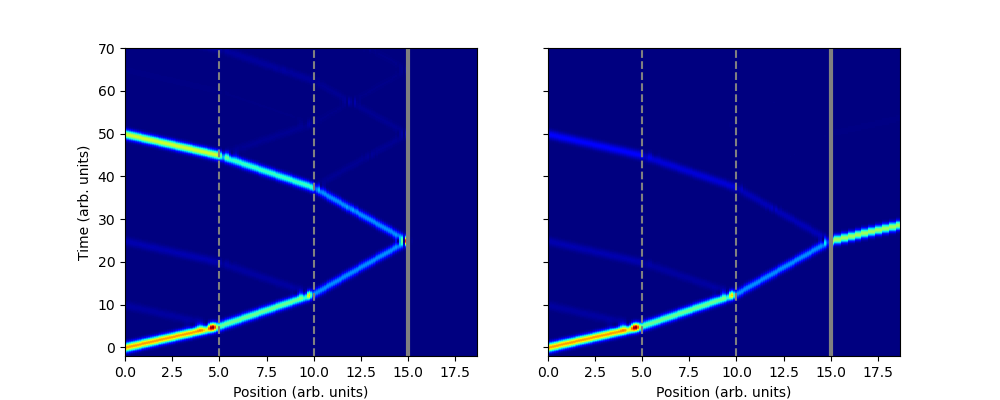

CPU times: user 18.9 s, sys: 6.27 s, total: 25.2 s
Wall time: 14.5 s


In [58]:
%%time
#time domain, intensity
c=1;
mt1=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss'];
a_s1 = d1['ai_pol_k']#[:,0::5]
b_s1 = d1['bi_pol_k']#[:,0::5]
pos1 = zpos1#[0::5]
boundaries1 = np.cumsum(d1['nums'])*d1['hs']

mt2=np.exp(-1j * np.outer(tv,kv) * c)*d2['gauss'];
a_s2 = d2['ai_pol_k']#[:,0::5]
b_s2 = d2['bi_pol_k']#[:,0::5]
pos2 = zpos2#[0::5]
boundaries2 = np.cumsum(d2['nums'])*d2['hs']

xlim = pos2[-1]
ylim = 70

width = 3

fig, ax = plt.subplots(1,2,figsize=(10,4),sharey=True)
Z1=np.abs(mt@(a_s1+b_s1))**2
ax[0].pcolor(pos1,tv,Z1,  vmax=abs(Z1).max(), vmin=0, cmap=plt.cm.jet)
#ax[0].set_title('a Intensity Vacuum + DBR')
ax[0].set_xlim([0,xlim])
ax[0].set_ylim([-2,ylim])
ax[0].set_xlabel('Position (arb. units)')
ax[0].set_ylabel('Time (arb. units)')
for i in range(len(boundaries1)-1):
    ax[0].axvline(boundaries1[i],ls='--',c='gray')
ax[0].axvline(boundaries1[-2],lw=width,c='gray')

Z2=np.abs(mt@(a_s2+b_s2))**2
ax[1].pcolor(pos2,tv,Z2,  vmax=abs(Z2).max(), vmin=0, cmap=plt.cm.jet)
#ax[0].set_title('a Intensity Vacuum + DBR')
ax[1].set_xlim([0,xlim])
ax[1].set_ylim([-2,ylim])
ax[1].set_xlabel('Position (arb. units)')
for i in range(len(boundaries2)-1):
    ax[1].axvline(boundaries2[i],ls='--',c='gray')
ax[1].axvline(boundaries2[-2],lw=width,c='gray')
plt.show()

# Save

In [21]:
np.savez('results0',momentum0m=momentum_0,momentum0l=momentum_0L,edges0=edges0,boundaries0=boundaries0,mst0=mst0,
             lor0=lor0, poyn0=poyn0)
np.savez('results1',edges1=edges1,boundaries1=boundaries1,mst1=mst1,
             lor1=lor1, poyn1=poyn1)
np.savez('results2',edges2=edges2,boundaries2=boundaries2,mst2=mst2,
             lor2=lor2, poyn2=poyn2)

# Stuff

In [60]:
def gr

SyntaxError: expected '(' (4259994877.py, line 1)

In [ ]:
%%time
# Trimmed

from tqdm import tqdm
# time domain, Poynting vector time derivative (z)

c, eps0, mu0=1, 1, 1
aik=d0['ai_pol_k'][:,0::5]/len(kv) # Only in medium portions
bik=d0['bi_pol_k'][:,0::5]/len(kv) 

k2,k1=np.meshgrid(kv,kv)

dh0=np.diff(zpos0)[0::5]
inds0=d0['n_factors'][2::5]
lor0=1j*np.zeros((len(dh0),len(tv)))
for i in tqdm(range(len(dh0))):
    ait=mt*aik[:,i].T
    bit=mt*bik[:,i].T
    mat1=-k1*k2*(1-np.exp(-1j*dh0[i]*(k1-k2)*inds0[i]))
    mat4=mat1.conj()
    mat3=k1*k2*(1-np.exp(1j*dh0[i]*(k1+k2)*inds0[i]))
    mat2=mat3.conj()
    lor0[i,:]= -(inds0[i]**2-1)/2/mu0**2*np.diag( \
        + ait.conj()@mat1@(ait).T + ait.conj()@mat2@(bit).T\
        + bit.conj()@mat3@(ait).T + bit.conj()@mat4@(bit).T)

In [ ]:
plt.figure(figsize=(6,4))

mlayb0=np.real(mst0)#[0::5])
mlayb1=np.real(mst1)#[0::5])
mlayb2=np.real(mst2)#[0::5])
plt.plot(tv1,np.cumsum(mlayb1[nums1[0]+nums1[1]]-mlayb1[nums1[0]]),label='MST c1')
plt.plot(tv1,np.cumsum(mlayb1[nums1[0]+nums1[1]+nums1[2]]-mlayb1[nums1[0]+nums1[1]]),label='MST c2')
plt.plot(tv1,np.cumsum(0-mlayb1[nums1[0]+nums1[1]+nums1[2]]),label='MST DBR')
plt.plot(tv1,np.cumsum(0-mlayb1[nums1[0]]),label='MST Whole')

lorlay=lor1
plt.plot(tv1,np.cumsum(np.sum(lorlay[nums1[0]:nums1[0]+nums1[1]],axis=0)),ls='--',label='Lorentz c1')
plt.plot(tv1,np.cumsum(np.sum(lorlay[nums1[0]+nums1[1]:nums1[0]+nums1[1]+nums1[2]],axis=0)),ls='--',label='Lorentz c2')
plt.plot(tv1,np.cumsum(np.sum(lorlay[nums1[0]+nums1[1]+nums1[2]:],axis=0)),ls='--',label='Lorentz DBR')
plt.plot(tv1,np.cumsum(np.sum(lorlay[nums1[0]:],axis=0)),ls='--',label='Lorentz Whole')

plt.title('Compare 1')
plt.xlabel('Time (arb. units)')
plt.ylabel('Impulse (arb. units)')

plt.legend()
plt.grid()
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(6,4))

mlay=np.real(mst1)#[0::5])
ax.plot(tv,np.cumsum(mlay[nums1[0]+nums1[1]]-mlay[nums1[0]]),label='MSTC1')
ax.plot(tv,np.cumsum(mlay[nums1[0]+nums1[1]+nums1[2]]-mlay[nums1[0]+nums1[1]]),label='MSTC2')
ax.plot(tv,np.cumsum(0-mlay[nums1[0]+nums1[1]+nums1[2]]),label='MSTDBR')

lorlay=np.real(lor1)#[2::5]
ax.plot(tv,np.cumsum(np.sum(lorlay[nums1[0]:nums1[0]+nums1[1]],axis=0)),ls='--',label='LC1')
ax.plot(tv,np.cumsum(np.sum(lorlay[nums1[0]+nums1[1]:nums1[0]+nums1[1]+nums1[2]],axis=0)),ls='--',label='LC1')
ax.plot(tv,np.cumsum(np.sum(lorlay[nums1[0]+nums1[1]+nums1[2]:-9],axis=0)),ls='--',label='LDBR')
plt.title('Compare')
plt.xlabel('Time (arb. units)')
plt.ylabel('Impulse (arb. units)')
plt.grid()
ax.legend()

In [ ]:
plt.figure(figsize=(6,4))

mlay=mst0
plt.plot(tv,np.cumsum(0-mlay[nums0[0]]))

lorlay=lor0
plt.plot(tv,np.cumsum(np.sum(lorlay[nums0[0]:],axis=0)),label='Lorentz DBR')
plt.ylabel('Impulse (arb. units)')
plt.xlabel('Time (arb. units)')
plt.grid()
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
Z=np.real(lor0).T
pc0=plt.pcolor(zpos0[2::5], tv, Z,   cmap=plt.cm.jet)
plt.xlim([0,12])
plt.ylim([0,16])
plt.xlabel('Physical Position (arb. units)')
plt.ylabel('Time (arb. units)')
cbar0 = fig.colorbar(pc0)
plt.show()

In [ ]:
#time domain, intensity

c=1;
mt=np.exp(-1j * np.outer(d0['t_values'],d0['k_values']) * c)*d0['gauss'];

plt.figure(figsize=(6,3))
Z=np.log(np.abs(mt@(d0['ai_pol_k']+d0['bi_pol_k']))**2)
plt.pcolor(zpos0,d0['t_values'],Z,  vmax=abs(Z).max(), vmin=0, cmap=plt.cm.jet)
plt.xlim([0,12])
plt.plot(zpos0,d0['n_factors'])
plt.xlabel('Physical Position (arb. units)')
plt.ylabel('Time (arb. units)/Refractive Index')
plt.ylim([-2,45])
plt.show()